# Atmospheric Energy Budget
Below I check if I can recreate the atmospheric energy budget.

In [1]:
import copy
import sys
import os
import inspect
from matplotlib.lines import Line2D
import scipy.optimize

from sympy.abc import lamda

from isca_tools.papers.miyawaki_2022 import get_dmse_dt
from isca_tools.plot.base import line_masked_lw
from isca_tools.thesis.adiabat_theory import get_z_ft_approx
from isca_tools.thesis.profile_fitting import get_tropopause_lev_ind
from isca_tools.thesis.surface_flux_taylor import name_square
from isca_tools.utils.base import mass_weighted_vertical_integral
from isca_tools.utils.fourier import coef_conversion
from isca_tools.utils.xarray import wrap_with_apply_ufunc, update_dim_slice, transpose_common_dims_like
from matplotlib.ticker import FuncFormatter, FixedLocator

# REMOTE - So can access functions in isca_tools which is in home/Isca directory
# sys.path.append(os.path.join(os.environ['HOME'], 'Isca'))
# LOCAL - So can access functions in isca_tools which is in StAndrews/Isca
sys.path.append(os.environ['PWD'])
import isca_tools
from isca_tools.utils.moist_physics import clausius_clapeyron_factor, sphum_sat, get_density
from isca_tools.utils.constants import kappa, L_v, c_p, c_p_water, rho_water, Stefan_Boltzmann, R, R_v, g
from isca_tools.utils import numerical
from isca_tools.utils.radiation import get_heat_capacity
from isca_tools.plot import colored_line, line_masked_lw
from isca_tools.thesis.surface_energy_budget_2layer import get_feedback_params
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
from tqdm.notebook import tqdm
from isca_tools.plot import fig_resize, update_fontsize, update_linewidth, savefig, label_subplots

from jobs.thesis_season.thesis_figs.utils import get_fourier_fit_xr, polyfit_phase_xr
import jobs.thesis_season.column.utils as utils

# Use custom matplotlib style for publishing
plt.style.use('/Users/joshduffield/Documents/StAndrews/Isca/jobs/tau_sweep/aquaplanet/publish_figures/publish.mplstyle')
ax_linewidth = plt.rcParams['axes.linewidth']

In [2]:
# exp_name = [f"thesis_season/column/depth={i}/k=1_abs=0_2" for i in [5, 20]]
exp_name = [f"thesis_season/column/depth={i}/fix_rh" for i in [5, 20]]
ds_base = utils.load_ds(exp_name=exp_name, lat_min=30, var_keep=utils.var_keep + ['drag_q', 'olr', 'sphum'],
                        low_lev_only=False)
# ds_base = isca_tools.load_dataset(exp_name[0], first_month_file=121)[['temp', 'sphum', 'olr', 'flux_lhe',
#                                                                  'flux_t', 'lwdn_sfc', 'lwup_sfc']]

  0%|          | 0/2 [00:00<?, ?it/s]

In [3]:
def get_p_eff(p_surf, temp=280, lapse_rate=6.5 / 1000):
    # Characteristic pressure for the q^* distribution, accounts for more q^* near the surface
    p_alpha_calc = 1000 * 100  # clausius clapeyron parameter is insensitive to pressure
    beta = clausius_clapeyron_factor(temp, p_alpha_calc) * lapse_rate * R * temp / g
    return (beta + 1) / (beta + 2) * p_surf


def get_temp_from_sphum_sat(sphum_sat_target, p, guess_temp: float = 280):
    fit_func = lambda x: sphum_sat(x, p) - sphum_sat_target
    return scipy.optimize.fsolve(fit_func, np.full_like(sphum_sat_target, guess_temp))


get_temp_from_sphum_sat_xr = wrap_with_apply_ufunc(get_temp_from_sphum_sat, input_core_dims=[[], []],
                                                   output_core_dims=[[]])

In [32]:
get_dmse_dt_xr = utils.wrap_with_apply_ufunc(get_dmse_dt,
                                             input_core_dims=[['time', 'pfull'], ['time', 'pfull'], ['time', 'pfull'],
                                                              ['pfull'], ['time']],
                                             output_core_dims=[['time'], ['time']])
ds_base['p_lev'] = ds_base.sigma_atm * ds_base.p_surf.max()
ds_base['atmos_energy_tend'] = get_dmse_dt_xr(ds_base.temp, ds_base.sphum, 0 * ds_base.sphum, ds_base.p_lev,
                                              ds_base.time * utils.day_seconds,
                                              spline_smoothing_factor=1e-5, zonal_mean=True)[1]
ds_base['atmos_flux_net'] = ds_base.lwup_sfc - ds_base.lwdn_sfc - ds_base.olr + ds_base.flux_lhe + ds_base.flux_t
ds_base['temp_col'] = mass_weighted_vertical_integral(ds_base.temp, ds_base.p_lev, 'pfull', simpson_method=True)

ds_base['sphum_col'] = mass_weighted_vertical_integral(ds_base.sphum, ds_base.p_lev, 'pfull', simpson_method=True)
ds_base['rh_col'] = ds_base['sphum_col'] / mass_weighted_vertical_integral(sphum_sat(ds_base.temp, ds_base.p_lev),
                                                                           ds_base.p_lev, 'pfull', simpson_method=True)
ds_base.attrs['p_eff'] = get_p_eff(float(ds_base.p_surf.max()))
ds_base['temp_col_sphum'] = get_temp_from_sphum_sat_xr(ds_base.sphum_col / ds_base.rh_col, ds_base.p_eff)

for key in ['col', 'col_sphum']:
    ds_base[f'temp_diseqb_{key}'] = ds_base.temp_atm - ds_base[f'temp_{key}']

ds = utils.get_annual_zonal_mean(ds_base)

## Atmospheric energy budget sanity check
Below I do a sanity check to ensure the vertically integrated atmosphere energy budget is satisfied:

$$\frac{1}{g} \int_0^{p_s} \frac{\partial(c_pT + L_v q)}{\partial t} dp = F_{\text{net}}$$

I plot the LHS and RHS separately below, and they seem to match well. I plot the error for each latitude below that with shading between 10th and 90th quantile, again it seems to be very small.

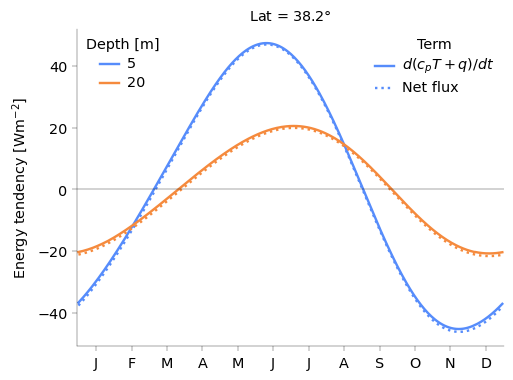

In [10]:
lat_plot_ind = 0
fig, ax = plt.subplots(1, 1, sharex=True)
fig_resize(fig, utils.width['two_col'])
for i in range(ds.depth.size):
    l1, = ax.plot(ds.time, ds.atmos_energy_tend.isel(lat=lat_plot_ind, depth=i), color=f"C{i}",
                  label=f'{ds.depth[i]:.0f}')
    l2, = ax.plot(ds.time, ds.atmos_flux_net.isel(lat=lat_plot_ind, depth=i), color=f"C{i}", linestyle=':')
    if i == 0:
        style_handles = [l1, l2]
update_linewidth(fig)
# First legend: depth colors
leg1 = ax.legend(title='Depth [m]', loc='upper left')
ax.add_artist(leg1)

ax.legend(style_handles, ['$d(c_pT+q)/dt$', 'Net flux'], title='Term', loc='upper right')
ax.axhline(0, color='k', lw=ax_linewidth)
ax.set_xlim(-1, 360)
ax.set_xticks(*utils.month_ticks)
ax.set_ylabel('Energy tendency [Wm$^{-2}$]')
ax.set_title(f'Lat = {ds.lat[lat_plot_ind]:.1f}$\degree$')
update_fontsize(fig, 6)
plt.show()

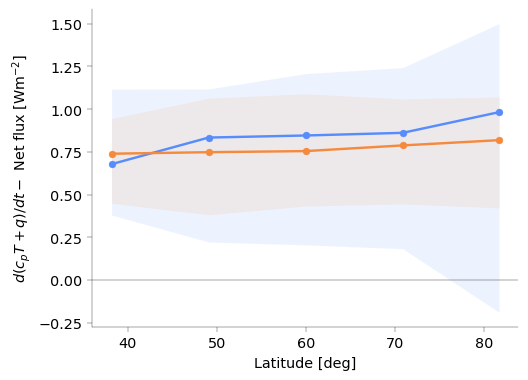

In [11]:
fig, ax = plt.subplots(1, 1, sharex=True)
fig_resize(fig, utils.width['two_col'])
for i in range(ds.depth.size):
    ax.plot(ds.lat, (ds_base.atmos_energy_tend - ds_base.atmos_flux_net).median(dim='time').isel(depth=i),
            color=f"C{i}", marker='.', markersize=10)
    ax.fill_between(ds.lat, (ds_base.atmos_energy_tend - ds_base.atmos_flux_net).isel(depth=i).quantile(0.1,
                                                                                                        dim='time').squeeze(),
                    (ds_base.atmos_energy_tend - ds_base.atmos_flux_net).isel(depth=i).quantile(0.9,
                                                                                                dim='time').squeeze(),
                    color=f"C{i}", alpha=0.1, lw=0)
update_linewidth(fig)
ax.axhline(0, color='k', lw=ax_linewidth)
ax.set_xlabel(utils.label_lat)
ax.set_ylabel('$d(c_pT+q)/dt - $ Net flux [Wm$^{-2}$]')
update_fontsize(fig, 6)
plt.show()

## Column humidity decomposition

The column specific humidity is given by: $q_{col} = \int_0^{p_s} q dp/p_s$. We define column relative humidity (standard definition) as $r_{col} = \int_0^{p_s} q dp/\int_0^{p_s} q^* dp$. Then we define effective pressure for humidity calculation according to:

$$p_{col, q} = \frac{\int_0^{p_s} q^* pdp}{\int_0^{p_s} q^* dp} \approx \frac{\beta+1}{\beta+2}p_s$$

where $\beta = \frac{\alpha(T) \Gamma R_d T}{g}$ using hydrostatic balance and assume temperature is dominant cause in variation with pressure of $q^*$, and $\alpha$ is the clausius clapeyron factor. Using values of $T=280$K, $\Gamma = 6.5$K/km, we get $p_{col,q}/p_s = 0.82$. This basically emphasizes that humidity is peaked closer to the surface than the total mass of the atmosphere (which would be $p_s/2$).

Given $p_{col,q}$ and $r_{col}$, we define a column humidity temperature, $T_{col,q}$, which satisfies $q_{col} = r_{col}q^*(T_{col,q}, p_{col,q})$.

We show below that the dominant seasonal variation in $q_{col}$ is then caused by $T_{col, q}$ which in itself has seasonal variation very close to the lowest model level temperature $T_a$.

All except the solid line neglect the seasonal cycle of column humidity, but this seems reasonable and quite a common assumption. The lines differ in what is used for the characteristic column temperature. We need to relate this to lowest model level temperature, but it seems we need to include an empirical factor, rather than a simple shift.

In [33]:
temp_diseqb_fit_coef = {}
for key in ['col', 'col_sphum']:
    # Force zero intercept as goes through mean
    temp_diseqb_fit_coef[key] = polyfit_phase_xr(ds.temp_atm - ds.temp_atm.mean(dim='time'),
                                                 ds[f'temp_diseqb_{key}'] - ds[f'temp_diseqb_{key}'].mean(dim='time'),
                                                 1, include_phase=False, coef_fix=[None, None, 0]).sel(deg='1')

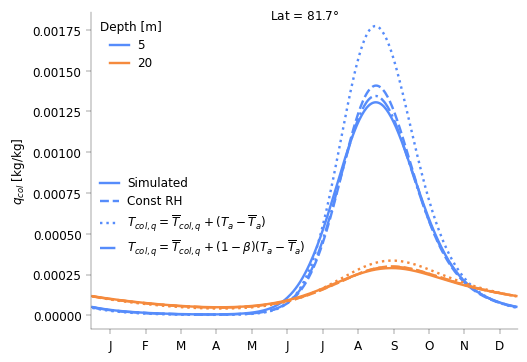

beta = [0.11 0.12] for depth = [ 5. 20.]


In [78]:
lat_plot_ind = -1
fig, ax = plt.subplots(1, 1, sharex=True)
fig_resize(fig, utils.width['two_col'])
for i in range(ds.depth.size):
    l1,  = ax.plot(ds.time, ds.sphum_col.isel(depth=i, lat=lat_plot_ind), color=f"C{i}", label=f'{ds.depth[i]:.0f}')
    l2, = ax.plot(ds.time, (ds.rh_col.mean(dim='time') * sphum_sat(ds.temp_col_sphum, ds.p_eff)).isel(depth=i, lat=lat_plot_ind),
            color=f"C{i}", linestyle='--')
    temp_col_sphum_use = ds.temp_col_sphum.mean(dim='time') +  ds.temp_atm-ds.temp_atm.mean(dim='time')
    l3, = ax.plot(ds.time, (ds.rh_col.mean(dim='time') * sphum_sat(temp_col_sphum_use, ds.p_eff)).isel(depth=i, lat=lat_plot_ind),
            color=f"C{i}", linestyle=':')
    temp_col_sphum_use = ds.temp_col_sphum.mean(dim='time') + (1-temp_diseqb_fit_coef['col_sphum']) * (ds.temp_atm-ds.temp_atm.mean(dim='time'))
    l4, = ax.plot(ds.time, (ds.rh_col.mean(dim='time') * sphum_sat(temp_col_sphum_use, ds.p_eff)).isel(depth=i, lat=lat_plot_ind),
            color=f"C{i}", linestyle='-.')
    # ax.plot(ds.time, ((ds.rh_col - ds.rh_col.mean(dim='time')) * sphum_sat(ds.temp_col_sphum, ds.p_eff)
    #                   ).isel(depth=i, lat=lat_plot_ind), color=f"C{i}", linestyle=':')
    if i == 0:
        style_handles = [l1, l2, l3, l4]
update_linewidth(fig)
# First legend: depth colors
leg1 = ax.legend(title='Depth [m]', loc='upper left')
ax.add_artist(leg1)

ax.legend(style_handles, ['Simulated', 'Const RH', '$T_{col, q}=\\overline{T}_{col, q} + (T_a-\\overline{T}_a)$',
                          '$T_{col, q}=\\overline{T}_{col, q} + (1-\\beta)(T_a-\\overline{T}_a)$'],
          loc='lower left', bbox_to_anchor=(0, 0.2))
ax.set_xlim(-1, 360)
ax.set_xticks(*utils.month_ticks)
ax.set_ylabel('$q_{col}$ [kg/kg]')
ax.set_title(f'Lat = {ds.lat[lat_plot_ind]:.1f}$\degree$', y=0.95)
update_fontsize(fig, 5)
plt.show()
print(f'beta = {np.round(temp_diseqb_fit_coef["col_sphum"].isel(lat=lat_plot_ind).values, 2)} for depth = {ds.depth.values}')

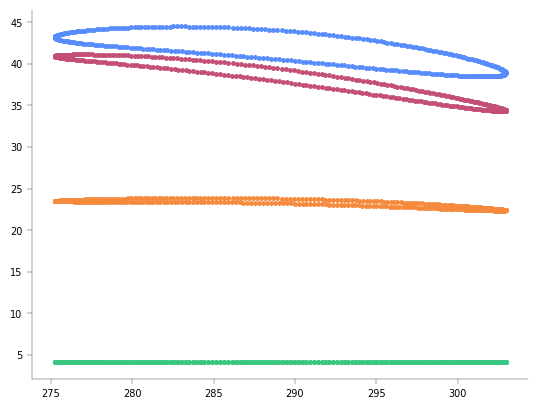

In [31]:
plt.scatter(ds.temp_atm.isel(depth=0, lat=0), ds.temp_atm.isel(depth=0, lat=0) - ds.temp_col.isel(depth=0, lat=0))
plt.scatter(ds.temp_atm.isel(depth=0, lat=0), ds.temp_atm.isel(depth=0, lat=0) - ds.temp_col_sphum.isel(depth=0, lat=0))
plt.scatter(ds.temp_atm.isel(depth=0, lat=0), ds.temp_atm.isel(depth=0, lat=0) - ds.temp_rad_atm.isel(depth=0, lat=0))
plt.scatter(ds.temp_atm.isel(depth=0, lat=0), ds.temp_atm.isel(depth=0, lat=0) - ds.temp_rad_surf.isel(depth=0, lat=0))

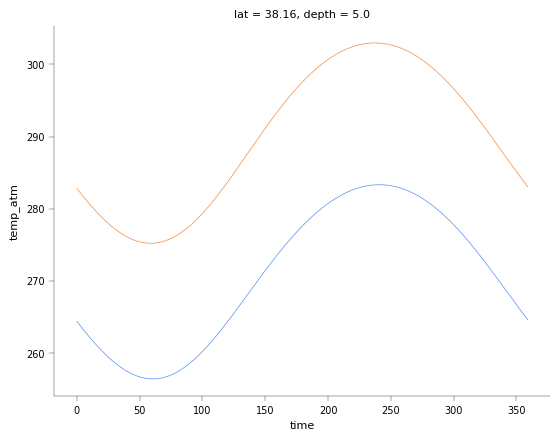

In [22]:
temp_rh_col.isel(depth=0, lat=0).plot()
ds.temp_atm.isel(depth=0, lat=0).plot()

TypeError: sphum_sat() missing 2 required positional arguments: 'temp' and 'pressure'

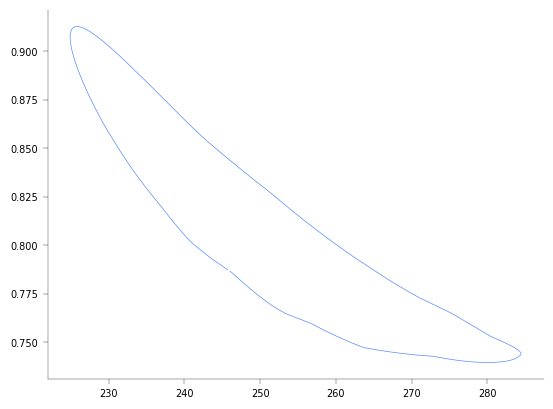

In [30]:
plt.plot(ds.temp_atm.isel(depth=0, lat=-1), ds.rh_col.isel(depth=0, lat=-1))
# ds.rh_col.isel(depth=1, lat=-1).plot()

In [24]:
L_v / R_v / 280 ** 2

0.06909589404559223

In [29]:
clausius_clapeyron_factor(280, 1000 * 100) * 6.5 / 1000 * R * 280 / g

3.673316958173053